# SAFETORCH Experiments 1: Clustering functions embeddings

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [23]:
def load_embeddings(csv_path: str) -> pd.DataFrame:
    """Load SAFE embeddings CSV (expects columns: exe, name, label, emb_0…emb_D)."""
    return pd.read_csv(csv_path)

In [24]:
def parse_filename(fn: str):
    """
    Splits a filename into (executable, option, compiler).
    """
    # Map from filename‐stem prefixes to your canonical program names:
    PREFIX_TO_PROGRAM = {
        "parse_xml": "cparserXML",
        "example":   "csimpleJSONparser",
        "http_parser": "benoitc_HTTP",
        "cjson": "cJSON",
        "picohttpparser": "picohttpparser",
        "calc": "yacc_calculator",
        "elf-parser": "elf_parser",
        "network_analyzer": "network_packet_analyzer",
        "packcc": "packcc",
        "pcap_parser": "pcap_parser",
    }

    # Compilers
    KNOWN_COMPILERS = {'gcc', 'clang'}
    # Optimization tokens
    OPT_TOKEN_MAP = {
        '0': 'O0', '1': 'O1', '2': 'O2', '3': 'O3',
        's': 'Os', 'fast': 'Ofast',
        'O0': 'O0', 'O1': 'O1', 'O2': 'O2', 'O3': 'O3',
        'Os': 'Os', 'Ofast': 'Ofast',
    }
    # strip extension
    stem = fn.rsplit(".", 1)[0]
    
    # find which prefix it starts with
    # take the longest matching key so that "parse_xml" beats "par" if both existed
    candidates = [p for p in PREFIX_TO_PROGRAM if stem.startswith(p)]
    if candidates:
        # pick the longest matching key
        best = max(candidates, key=len)
        program = PREFIX_TO_PROGRAM[best]
        remainder = stem[len(best):].lstrip("_")
    else:
        # fallback: use everything before first underscore
        parts = stem.split("_", 1)
        program = parts[0]
        remainder = parts[1] if len(parts) > 1 else ""
    
    # split off settings tokens
    settings = remainder.split("_") if remainder else []
    
    # compiler: first known compiler in settings, else default gcc
    compiler = next((s for s in settings if s in KNOWN_COMPILERS), "gcc")
    
    # optimization: map tokens via OPT_TOKEN_MAP or keep digits
    opts = []
    for s in settings:
        if s in OPT_TOKEN_MAP:
            opts.append(OPT_TOKEN_MAP[s])
        elif s.isdigit():
            opts.append(s)
    option = "_".join(opts) if opts else "default"
    
    return program, option, compiler

def enrich_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'program', 'option', 'compiler' columns to a DataFrame
    with an existing 'filename' column.
    """
    parsed = df["filename"].apply(parse_filename)
    df = df.copy()
    df[["program", "option", "compiler"]] = pd.DataFrame(parsed.tolist(), index=df.index)
    # Remove the 'filename' column as it's no longer needed
    df.drop(columns=["filename"], inplace=True)
    # Merge the all the embedding columns into a single column
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    df["embeddings"] = df[emb_cols].apply(lambda row: row.tolist(), axis=1)
    # Drop the individual embedding columns
    df.drop(columns=emb_cols, inplace=True)
    return df

In [25]:
path = "../safetorch/outputs/all_function_embeddings.csv"
df = load_embeddings(path)

print(f"Loaded {len(df)} SAFE embeddings (= functions).")
print(f"Columns in DataFrame: {df.columns.tolist()}\n")
print(f"Unique executables (filenames): {df['filename'].unique().tolist()}")


Loaded 7898 SAFE embeddings (= functions).
Columns in DataFrame: ['filename', 'name', 'address', 'label', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_54', 'emb_55', 'emb_56', 'emb_57', 'emb_58', 'emb_59', 'emb_60', 'emb_61', 'emb_62', 'emb_63', 'emb_64', 'emb_65', 'emb_66', 'emb_67', 'emb_68', 'emb_69', 'emb_70', 'emb_71', 'emb_72', 'emb_73', 'emb_74', 'emb_75', 'emb_76', 'emb_77', 'emb_78', 'emb_79', 'emb_80', 'emb_81', 'emb_82', 'emb_83', 'emb_84', 'emb_85', 'emb_86', 'emb_87', 'emb_88', 'emb_89', 'emb

In [26]:
# enrich the DataFrame with program, option, compiler columns
df = enrich_df(df) 
# Save to a csv file
df.to_csv("../safetorch/outputs/all_function_embeddings_enriched.csv", index=False)

df.head()

,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


In [27]:
# Print dataframe information
print("DataFrame Information:")
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
print(f"Unique options (total len {len(df['option'].unique().tolist())}): {df['option'].unique().tolist()}")
print(f"Unique compilers: {df['compiler'].unique().tolist()}")

DataFrame Information:
Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']
Unique options (total len 14): ['O2_32', 'Ofast_32', 'O0_32', 'O2', 'O1_32', 'Os_32', 'O1', 'O3', 'Ofast', 'O3_32', 'Os', '32', 'default', 'O0']
Unique compilers: ['gcc', 'clang']


## Cluster functions Test 1 (with database) Elbow Plot with Inertia + kmeans

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from typing import Tuple, Dict
from kneed import KneeLocator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
def build_reference_clusters_elbow(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 2,
    k_max: int = 10
) -> Tuple[KMeans, Dict[int, float], int]:
    """
    Build a reference clustering model using all programs except `leave_out_program`.
    Automatically selects optimal k based on the elbow (inertia) method, and plots the
    inertia vs. k curve with the elbow annotated.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'program', 'embeddings', and 'label' columns.
    leave_out_program : str
        Program to leave out when building reference.
    k_min : int
        Minimum k to consider (default: 2).
    k_max : int
        Maximum k to consider (default: 10).

    Returns
    -------
    kmeans : KMeans
        Trained KMeans model on reference data.
    cluster_label_map : dict
        Mapping from cluster index to majority true label.
    best_k : int
        Selected number of clusters.
    """
    # 1) Filter reference data
    ref = df[df['program'] != leave_out_program].copy()
    X_ref = np.vstack(ref['embeddings'].values)
    labels_ref = ref['label'].astype(float).values

    print(f"Reference dataset: {len(X_ref)} entries (excluding '{leave_out_program}').")

    # 2) Compute inertia for each k
    max_k = min(k_max, len(X_ref) - 1)
    ks = list(range(k_min, max_k + 1))
    inertias = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=0)
        km.fit(X_ref)
        inertias.append(km.inertia_)

    # 3) Use KneeLocator to find the elbow
    kl = KneeLocator(
        ks, inertias,
        curve='convex',
        direction='decreasing',
        online=True
    )
    best_k = kl.elbow or ks[np.argmin(inertias)]  # fallback to min inertia

    print(f"Selected k = {best_k} (elbow point).")

    # 4) Plot inertia vs. k with elbow marked
    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, marker='o', label='Inertia')
    if kl.elbow:
        plt.axvline(best_k, color='red', linestyle='--', label=f'Elbow at k={best_k}')
    plt.title("Elbow Method for KMeans: Inertia vs. k")
    plt.xlabel("Number of clusters k")
    plt.ylabel("Inertia (within‑cluster sum of squares)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 5) Fit final model with best_k
    kmeans = KMeans(n_clusters=best_k, random_state=0).fit(X_ref)
    cluster_ids = kmeans.labels_

    # 6) Map each cluster to its majority true label
    df_ref = pd.DataFrame({'cluster': cluster_ids, 'label': labels_ref})
    cluster_label_map = (
        df_ref
        .groupby('cluster')['label']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )

    return kmeans, cluster_label_map, best_k

In [19]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    kmeans: KMeans,
    cluster_label_map: Dict[int, float]
) -> pd.DataFrame:
    """
    Classify entries of `program_name` by nearest reference cluster.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with 'program', 'embeddings'.
    program_name : str
        Program to classify.
    kmeans : KMeans
        Fitted KMeans model on reference data.
    cluster_label_map : dict
        Mapping from cluster index to majority label.

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with added column 'predicted_label'.
    """
    test = df[df['program'] == program_name].copy()
    if test.empty:
        raise ValueError(f"No entries found for program '{program_name}'")
    
    X_test = np.vstack(test['embeddings'].values)
    assigned_clusters = kmeans.predict(X_test)
    predicted_labels = [cluster_label_map[c] for c in assigned_clusters]
    
    test['cluster'] = assigned_clusters
    test['predicted_label'] = predicted_labels
    return test

In [20]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Selected k = 5 (elbow point).


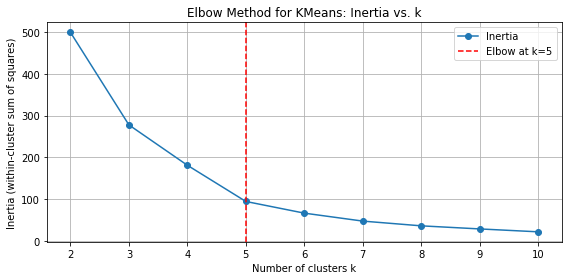

Reference model built with k=5 clusters.
Cluster label map - majority class (cluster_id: label): {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}


In [21]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
kmeans, cluster_label_map, best_k =  build_reference_clusters_elbow(df, leave_out_program=leave_out_program, k_min=2, k_max=10)
print(f"Reference model built with k={best_k} clusters.")
print(f"Cluster label map - majority class (cluster_id: label): {cluster_label_map}")

In [47]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    kmeans=kmeans,
    cluster_label_map=cluster_label_map
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,cluster,predicted_label
6096,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",1,0.0
6097,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",1,0.0
6098,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",3,0.0
6099,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",3,0.0
6100,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1,0.0


In [15]:
from sklearn.metrics import recall_score
import numpy as np

In [ ]:
def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [48]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.0}


In [45]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.0}


In [42]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.0}


In [39]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.0}


In [36]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.0}


In [33]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.0}


In [30]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.823076923076923}


In [27]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.0}


In [20]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.0}


In [17]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.0}


In [ ]:
import numpy as np

values = [0,0,0,0,0,0,0,0,0, 0.82]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.08199999999999999
Std: 0.246


## Cluster functions Test 1 (with database) TSNE with 2 dimensions + Elbow Plot with Inertia + kmeans

In [180]:
import ast
from typing import Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [181]:
def _ensure_embeddings_array(col: pd.Series) -> np.ndarray:
    """Convert a Series of embeddings (list/ndarray or string like '[0.1, 0.2]') to a 2D numpy array."""
    if len(col) == 0:
        return np.zeros((0, 0))
    first = col.iloc[0]
    if isinstance(first, str):
        arrs = col.apply(lambda s: np.array(ast.literal_eval(s), dtype=float))
    else:
        arrs = col.apply(lambda x: np.array(x, dtype=float))
    return np.vstack(arrs.values)


def tsne_reduce_all(
    df: pd.DataFrame,
    embeddings_col: str = "embeddings",
    n_components: int = 2,
    random_state: int = 0,
    perplexity: Optional[int] = None,
    init: str = "pca",
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Run sklearn TSNE on ALL rows of df and return (df_with_dims, X_2d).
    This computes t-SNE on the combined dataset (reference + left-out).

    Additionally: produces a scatter plot of the 2D embedding. If the DataFrame
    contains a 'program' column points are colored by program (categorical).
    """
    df_copy = df.copy()
    X = _ensure_embeddings_array(df_copy[embeddings_col])
    n_samples = len(X)
    if n_samples < 2:
        raise ValueError("Need at least 2 samples for TSNE.")

    # choose perplexity safely (< n_samples)
    if perplexity is None:
        perp = min(30, max(5, (n_samples - 1) // 3))
    else:
        perp = int(perplexity)
        if perp >= n_samples:
            perp = max(2, (n_samples - 1) // 3)

    ts = TSNE(
        n_components=n_components,
        perplexity=perp,
        init=init,
        random_state=random_state,
        learning_rate="auto",
    )
    X_2d = ts.fit_transform(X)

    # attach dims to dataframe (dim1, dim2)
    if n_components >= 1:
        df_copy["dim1"] = X_2d[:, 0]
    if n_components >= 2:
        df_copy["dim2"] = X_2d[:, 1]

    # -------------------------
    # Plot the 2D embedding
    # -------------------------
    try:
        plt.figure(figsize=(8, 6))
        if "program" in df_copy.columns:
            programs = df_copy["program"].astype(str).values
            uniq = np.unique(programs)
            # color map: use tab20 (up to 20 distinct colors); if more, cycle colors
            cmap = plt.get_cmap("tab20")
            color_idx = {p: i % 20 for i, p in enumerate(uniq)}
            colors = [cmap(color_idx[p]) for p in programs]

            sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=30, alpha=0.85, edgecolor="none")

            # show legend if not too many programs
            if len(uniq) <= 20:
                # create legend handles
                handles = []
                for p in uniq:
                    handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                              markerfacecolor=cmap(color_idx[p]), markersize=7))
                plt.legend(handles, uniq, title="program", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
            else:
                plt.title(f"t-SNE 2D embedding (colored by program) — {len(uniq)} programs")
        else:
            plt.scatter(X_2d[:, 0], X_2d[:, 1], s=30, alpha=0.85, edgecolor="none")
            plt.title("t-SNE 2D embedding")

        plt.xlabel("dim1")
        plt.ylabel("dim2")
        plt.grid(False)
        plt.tight_layout()
        plt.show()
    except Exception:
        # plotting must not break the function — silently continue on failure
        pass

    return df_copy, X_2d

def build_reference_clusters_elbow(
    df_with_dims: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 2,
    k_max: int = 10,
) -> Tuple[KMeans, Dict[int, object], int]:
    """
    Use the 2D coordinates (columns 'dim1' and 'dim2') in df_with_dims and:
      - exclude rows where program == leave_out_program (reference set),
      - compute inertias for k in k_min..k_max,
      - select elbow with KneeLocator,
      - fit final KMeans on reference 2D coords,
      - return (kmeans, cluster_label_map, best_k).

    df_with_dims must already contain 'dim1' and 'dim2' (produced by tsne_reduce_all).
    """
    if "program" not in df_with_dims.columns:
        raise ValueError("df_with_dims must contain a 'program' column.")
    if "dim1" not in df_with_dims.columns or "dim2" not in df_with_dims.columns:
        raise ValueError("df_with_dims must contain 'dim1' and 'dim2' (run tsne_reduce_all first).")
    if leave_out_program not in df_with_dims["program"].unique():
        raise ValueError(f"leave_out_program '{leave_out_program}' not found in df_with_dims['program'].")

    # reference rows and coords
    ref_mask = df_with_dims["program"] != leave_out_program
    X_ref_2d = np.vstack([df_with_dims.loc[ref_mask, "dim1"].values, df_with_dims.loc[ref_mask, "dim2"].values]).T
    labels_ref = df_with_dims.loc[ref_mask, "label"].values

    if len(X_ref_2d) < 2:
        raise ValueError("Reference set too small after leaving out program.")

    # compute inertias in range
    max_k = min(k_max, len(X_ref_2d) - 1)
    if max_k < k_min:
        raise ValueError(f"Not enough reference points ({len(X_ref_2d)}) for requested k range.")
    ks = list(range(k_min, max_k + 1))
    inertias = []
    for k in ks:
        km_tmp = KMeans(n_clusters=k, random_state=0)
        km_tmp.fit(X_ref_2d)
        inertias.append(km_tmp.inertia_)

    # find elbow
    kl = KneeLocator(ks, inertias, curve="convex", direction="decreasing", online=True)
    best_k = int(kl.elbow) if kl.elbow is not None else int(ks[np.argmin(inertias)])

    # plot inertia vs k
    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, marker="o", label="Inertia")
    if kl.elbow is not None:
        plt.axvline(best_k, color="red", linestyle="--", label=f"Elbow at k={best_k}")
    plt.title("Elbow Method (KMeans) on TSNE 2D reference coords")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # fit final kmeans on reference 2D
    kmeans = KMeans(n_clusters=best_k, random_state=0).fit(X_ref_2d)
    cluster_ids = kmeans.labels_

    # cluster -> majority true label
    df_ref = pd.DataFrame({"cluster": cluster_ids, "label": labels_ref})
    cluster_label_map = df_ref.groupby("cluster")["label"].agg(lambda x: x.mode().iloc[0]).to_dict()

    # optional scatter of reference embedding colored by cluster
    try:
        plt.figure(figsize=(7, 6))
        plt.scatter(X_ref_2d[:, 0], X_ref_2d[:, 1], c=cluster_ids, s=20)
        plt.title(f"Reference TSNE embedding (k={best_k})")
        plt.xlabel("dim1")
        plt.ylabel("dim2")
        plt.tight_layout()
        plt.show()
    except Exception:
        pass

    return kmeans, cluster_label_map, best_k


def classify_program_entries_tsne(
    df_with_dims: pd.DataFrame,
    program_name: str,
    kmeans: KMeans,
    cluster_label_map: Dict[int, object],
) -> pd.DataFrame:
    """
    Classify `program_name` rows using their TSNE 2D coordinates already present in df_with_dims
    (expects 'dim1' and 'dim2' columns present).
    Returns the subset DataFrame with added 'cluster' and 'predicted_label' and dim columns.
    """
    if "dim1" not in df_with_dims.columns or "dim2" not in df_with_dims.columns:
        raise ValueError("df_with_dims must contain 'dim1' and 'dim2' columns (run tsne_reduce_all first).")

    test = df_with_dims[df_with_dims["program"] == program_name].copy()
    if test.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    coords = np.vstack([test["dim1"].values, test["dim2"].values]).T
    assigned_clusters = kmeans.predict(coords)
    predicted_labels = [cluster_label_map.get(int(c), None) for c in assigned_clusters]

    test = test.reset_index(drop=True)
    test["cluster"] = assigned_clusters
    test["predicted_label"] = predicted_labels
    return test

In [182]:
def classify_program_entries_tsne(
    df_with_dims: pd.DataFrame,
    program_name: str,
    kmeans: KMeans,
    cluster_label_map: Dict[int, object],
) -> pd.DataFrame:
    """
    Classify `program_name` rows using their TSNE 2D coordinates already present in df_with_dims
    (expects 'dim1' and 'dim2' columns present).
    Returns the subset DataFrame with added 'cluster' and 'predicted_label' and dim columns.
    """
    if "dim1" not in df_with_dims.columns or "dim2" not in df_with_dims.columns:
        raise ValueError("df_with_dims must contain 'dim1' and 'dim2' columns (run tsne_reduce_all first).")

    test = df_with_dims[df_with_dims["program"] == program_name].copy()
    if test.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    coords = np.vstack([test["dim1"].values, test["dim2"].values]).T
    assigned_clusters = kmeans.predict(coords)
    predicted_labels = [cluster_label_map.get(int(c), None) for c in assigned_clusters]

    test = test.reset_index(drop=True)
    test["cluster"] = assigned_clusters
    test["predicted_label"] = predicted_labels
    return test

/home/marcos/.local/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


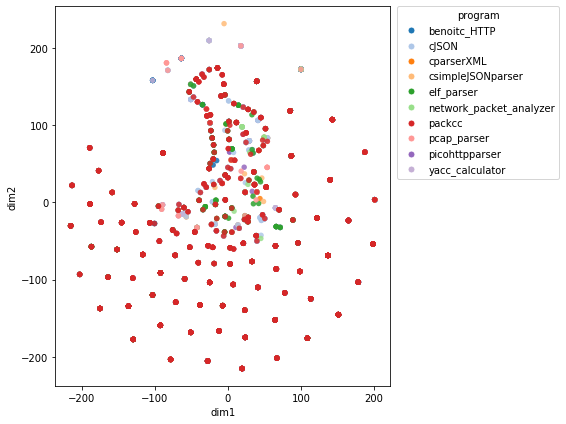

,name,address,label,program,option,compiler,embeddings,dim1,dim2
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727...",86.726181,60.072620
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034...",136.825073,-68.907326
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101...",142.836548,107.027145
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760...",52.341820,19.591814
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05...",-88.773582,63.755459


In [183]:
# 1) Run TSNE on the whole dataset
df_tsne, X_all_2d = tsne_reduce_all(df, random_state=42)

df_tsne.head()

In [187]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


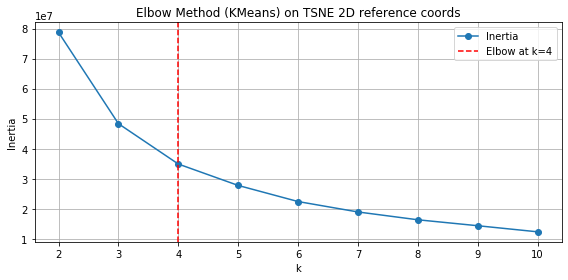

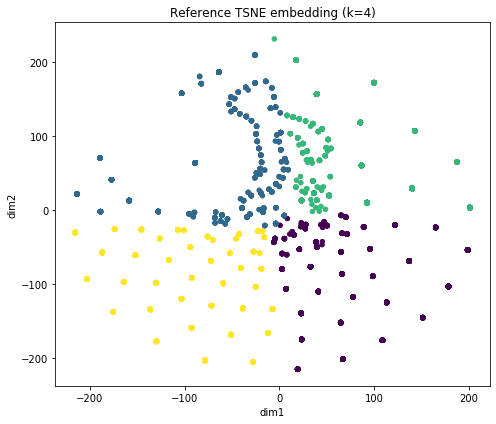

In [216]:
# 2) Build reference clusters (exclude the program of interest)
leave_out_program="packcc"

kmeans, cluster_label_map, best_k = build_reference_clusters_elbow(
    df_tsne, leave_out_program=leave_out_program
)

In [217]:
results = classify_program_entries_tsne(
    df_tsne, 
    program_name=leave_out_program,
    kmeans=kmeans, 
    cluster_label_map=cluster_label_map
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,dim1,dim2,cluster,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",-0.124337,31.832449,1,1
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",-43.396641,159.340866,1,1
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",-7.278236,-133.841537,3,0
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",-151.809631,-61.124218,3,0
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",-88.773582,63.755459,1,1


In [190]:
from sklearn.metrics import recall_score
import numpy as np

def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [191]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.0}


In [194]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.0}


In [197]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.0}


In [200]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.6115384615384616}


In [203]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.0}


In [206]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.0}


In [209]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.0}


In [212]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.0}


In [215]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.0}


In [218]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.5752688172043011}


In [219]:
import numpy as np

values = [0.0, 0.0, 0.0, 0.61, 0.0, 0.0, 0.0, 0.0, 0.0, 0.57]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.118
Std: 0.23616943070600815


## Cluster functions Test 2 (with database) KNN + Majority Closer Points (k=4)

In [51]:
from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
import warnings
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_is_fitted

In [52]:
def build_reference_knn_elbow_cosine(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 1,
    k_max: int = 10,
    validation_frac: float = 0.0,
    random_state: int = 0,
    n_jobs: int = -1,
    scoring_on: str = "accuracy",
    elbow_tol: float = 1e-8
) -> Tuple[KNeighborsClassifier, Dict[int, float], int]:
    """
    Build a k-NN classifier (using COSINE distance) excluding `leave_out_program`
    and choose k using the Elbow / "knee" method on the error curve.

    By default this uses *resubstitution error* (train and test on the same ref set)
    which is fast but optimistic. To use a single hold-out for evaluation set
    validation_frac in (0,1) (e.g. 0.2).

    Returns:
      knn_final: fitted KNeighborsClassifier(metric='cosine', algorithm='brute')
      cv_scores: dict mapping n_neighbors -> mean score (higher is better)
      best_k: selected k by elbow method
    """
    # required columns
    required_cols = {'program', 'embeddings', 'label'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"DataFrame must contain columns: {missing}")

    # reference set
    ref = df[df['program'] != leave_out_program].copy()
    if ref.shape[0] == 0:
        raise ValueError(f"No reference rows left after excluding program '{leave_out_program}'")

    # stack embeddings robustly
    try:
        X_ref = np.vstack(ref['embeddings'].values)
    except Exception as e:
        raise ValueError("Could not stack embeddings — ensure each 'embeddings' entry is array-like of the same length.") from e
    y_ref = ref['label'].astype(int).values
    n_samples = X_ref.shape[0]
    print(f"Reference dataset: {n_samples} entries (excluding '{leave_out_program}').")

    # k range
    max_possible_k = max(1, n_samples - 1)
    max_k = min(k_max, max_possible_k)
    if max_k < k_min:
        raise ValueError(f"k_min={k_min} is too large for the reference size (max allowed is {max_k}).")
    ks = list(range(k_min, max_k + 1))

    # If validation_frac provided, create a single stratified split
    use_validation = False
    if validation_frac is not None and 0.0 < validation_frac < 1.0:
        if len(np.unique(y_ref)) < 2:
            warnings.warn("Less than two classes in reference; validation split ignored.")
        else:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=validation_frac, random_state=random_state)
            train_idx, val_idx = next(sss.split(X_ref, y_ref))
            X_train_eval, X_val = X_ref[train_idx], X_ref[val_idx]
            y_train_eval, y_val = y_ref[train_idx], y_ref[val_idx]
            use_validation = True

    # compute score for each k (no cross-validation here)
    scores: Dict[int, float] = {}
    for k in ks:
        # cosine distance requires brute-force algorithm in sklearn
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
        if use_validation:
            # train on train_eval, evaluate on held-out validation
            knn_tmp.fit(X_train_eval, y_train_eval)
            score = knn_tmp.score(X_val, y_val)  # accuracy by default
        else:
            # resubstitution: train and test on full reference set (optimistic)
            knn_tmp.fit(X_ref, y_ref)
            score = knn_tmp.score(X_ref, y_ref)
        scores[k] = float(score)

    # convert to error curve (assuming score in [0,1], larger is better)
    ks_arr = np.array(ks, dtype=float)
    errors = np.array([1.0 - scores[k] for k in ks], dtype=float)

    # elbow detection
    if len(ks_arr) == 1:
        best_k = int(ks_arr[0])
        print(f"Only one k to evaluate. Selected k = {best_k}.")
    else:
        x1, y1 = ks_arr[0], errors[0]
        x2, y2 = ks_arr[-1], errors[-1]
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom <= elbow_tol:
            # degenerate -> pick best score (tie-breaker: smallest k)
            best_score = max(scores.values())
            best_candidates = [k for k, v in scores.items() if v == best_score]
            best_k = min(best_candidates)
            print("Elbow detection degenerate (endpoints nearly identical). Falling back to best-score selection.")
        else:
            numerators = np.abs((y2 - y1) * ks_arr - (x2 - x1) * errors + x2 * y1 - y2 * x1)
            distances = numerators / denom
            max_idx = int(np.argmax(distances))
            best_k_candidate = int(ks_arr[max_idx])
            max_dist = distances[max_idx]
            if max_dist <= elbow_tol:
                best_score = max(scores.values())
                best_candidates = [k for k, v in scores.items() if v == best_score]
                best_k = min(best_candidates)
                print("No pronounced elbow detected (max distance tiny). Falling back to best-score selection.")
            else:
                best_k = best_k_candidate
                print(f"Elbow detected at k = {best_k} (max perpendicular distance = {max_dist:.6g}).")

    # fit final model on full reference set using cosine distance
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
    knn_final.fit(X_ref, y_ref)

    # plot error curve and mark selection
    plt.figure(figsize=(8, 4))
    plt.plot(ks_arr, errors, marker='o', label='error (1 - score)')
    plt.scatter([best_k], [1.0 - scores[best_k]], color='red', zorder=5, label=f'selected k = {best_k}')
    plt.annotate(f"k={best_k}\nscore={scores[best_k]:.3f}",
                 xy=(best_k, 1.0 - scores[best_k]),
                 xytext=(10, -25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    plt.title(f"Cosine KNN - error vs n_neighbors (elbow method) [{'validation' if use_validation else 'resubstitution'}]")
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Error (1 - score)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return knn_final, scores, best_k

In [ ]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    knn: KNeighborsClassifier,
    return_proba: bool = False,
    proba_col: str = "predicted_proba"
) -> pd.DataFrame:
    """
    Classify entries of `program_name` using a trained KNN classifier.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with at least 'program' and 'embeddings' columns.
    program_name : str
        Program to classify.
    knn : KNeighborsClassifier
        Trained KNN classifier on reference data (must be fitted).
    return_proba : bool
        If True and the classifier supports predict_proba, adds `proba_col` column
        with the maximum predicted probability per row (float in [0,1]).
    proba_col : str
        Column name to store predicted probability (when return_proba is True).

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with new column(s):
        - 'predicted_label': predicted label from KNN classifier
        - optionally `proba_col` with float max probability (if available & requested)
    """
    # 1) Filter and basic checks
    if 'program' not in df.columns or 'embeddings' not in df.columns:
        raise ValueError("DataFrame must contain 'program' and 'embeddings' columns.")

    test_df = df.loc[df['program'] == program_name].copy()
    if test_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    # 2) Check that KNN is fitted
    try:
        check_is_fitted(knn)
    except Exception as e:
        raise ValueError("Provided `knn` does not appear to be fitted. Call `.fit()` first.") from e

    # 3) Prepare X_test robustly
    try:
        # Convert to array-like and stack. This handles lists/1D arrays/ndarrays.
        emb_list = list(test_df['embeddings'].values)
        X_test = np.stack([np.asarray(e) for e in emb_list], axis=0)
    except Exception as exc:
        # Provide a helpful error message
        raise ValueError(
            "Error preparing embeddings for prediction. Ensure each 'embeddings' entry "
            "is array-like of the same length. Original error: " + str(exc)
        ) from exc

    # 4) Predict labels
    try:
        # "Classification is computed from a simple majority vote of the nearest neighbors of each point"
        # See link https://scikit-learn.org/stable/modules/neighbors.html
        predicted_labels = knn.predict(X_test)
    except Exception as exc:
        raise RuntimeError("Error during knn.predict: " + str(exc)) from exc

    test_df['predicted_label'] = predicted_labels

    # 5) Optionally add predicted probability/confidence
    if return_proba:
        if hasattr(knn, "predict_proba"):
            try:
                probs = knn.predict_proba(X_test)  # shape (n_samples, n_classes)
                # store the max class probability as a simple confidence scalar
                max_probs = probs.max(axis=1)
                test_df[proba_col] = max_probs
            except Exception as exc:
                # If predict_proba exists but fails, warn / raise as appropriate
                raise RuntimeError("Error during knn.predict_proba: " + str(exc)) from exc
        else:
            raise ValueError("The provided KNN classifier does not support `predict_proba`. "
                             "Train with `probability=True` (or use a classifier that supports it).")

    # 6) Reset index for clarity and return
    test_df.reset_index(drop=True, inplace=True)
    return test_df

In [54]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Elbow detected at k = 4 (max perpendicular distance = 0.125954).


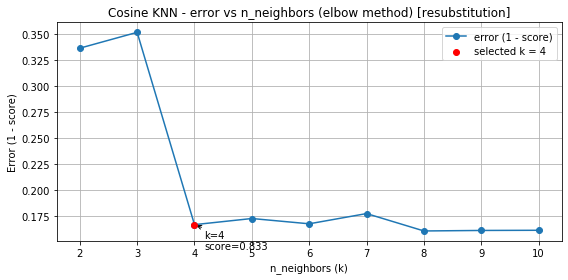

Reference model built with k=4 clusters.


In [84]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
knn_final, cv_scores, best_k =  build_reference_knn_elbow_cosine(df, leave_out_program=leave_out_program, k_min=2, k_max=10)

print(f"Reference model built with k={best_k} clusters.")

In [85]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    knn=knn_final
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",0
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",0
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",0
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",0
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1


In [57]:
from sklearn.metrics import recall_score
import numpy as np

In [58]:
def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [86]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.45878136200716846}


In [83]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.03571428571428571}


In [80]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.7729257641921398}


In [77]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.017857142857142856}


In [74]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.0}


In [71]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.7894736842105263}


In [68]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.5769230769230769}


In [65]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.03260869565217391}


In [62]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.5748502994011976}


In [59]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.4852941176470588}


In [3]:
import numpy as np

values = [0.57,0.03,0.78,0.48,0.57,0,0.035,0.01,0.45,0.77]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.3695
Std: 0.30346704928212553


## Cluster functions Test 2 (with database) KNN + Majority Closer Points (k=5)

In [7]:
from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
import warnings
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_is_fitted

In [8]:
def build_reference_knn_elbow_cosine(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 1,
    k_max: int = 10,
    validation_frac: float = 0.0,
    random_state: int = 0,
    n_jobs: int = -1,
    scoring_on: str = "accuracy",
    elbow_tol: float = 1e-8
) -> Tuple[KNeighborsClassifier, Dict[int, float], int]:
    """
    Build a k-NN classifier (using COSINE distance) excluding `leave_out_program`
    and choose k using the Elbow / "knee" method on the error curve.

    By default this uses *resubstitution error* (train and test on the same ref set)
    which is fast but optimistic. To use a single hold-out for evaluation set
    validation_frac in (0,1) (e.g. 0.2).

    Returns:
      knn_final: fitted KNeighborsClassifier(metric='cosine', algorithm='brute')
      cv_scores: dict mapping n_neighbors -> mean score (higher is better)
      best_k: selected k by elbow method
    """
    # required columns
    required_cols = {'program', 'embeddings', 'label'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"DataFrame must contain columns: {missing}")

    # reference set
    ref = df[df['program'] != leave_out_program].copy()
    if ref.shape[0] == 0:
        raise ValueError(f"No reference rows left after excluding program '{leave_out_program}'")

    # stack embeddings robustly
    try:
        X_ref = np.vstack(ref['embeddings'].values)
    except Exception as e:
        raise ValueError("Could not stack embeddings — ensure each 'embeddings' entry is array-like of the same length.") from e
    y_ref = ref['label'].astype(int).values
    n_samples = X_ref.shape[0]
    print(f"Reference dataset: {n_samples} entries (excluding '{leave_out_program}').")

    # k range
    max_possible_k = max(1, n_samples - 1)
    max_k = min(k_max, max_possible_k)
    if max_k < k_min:
        raise ValueError(f"k_min={k_min} is too large for the reference size (max allowed is {max_k}).")
    ks = list(range(k_min, max_k + 1))

    # If validation_frac provided, create a single stratified split
    use_validation = False
    if validation_frac is not None and 0.0 < validation_frac < 1.0:
        if len(np.unique(y_ref)) < 2:
            warnings.warn("Less than two classes in reference; validation split ignored.")
        else:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=validation_frac, random_state=random_state)
            train_idx, val_idx = next(sss.split(X_ref, y_ref))
            X_train_eval, X_val = X_ref[train_idx], X_ref[val_idx]
            y_train_eval, y_val = y_ref[train_idx], y_ref[val_idx]
            use_validation = True

    # compute score for each k (no cross-validation here)
    scores: Dict[int, float] = {}
    for k in ks:
        # cosine distance requires brute-force algorithm in sklearn
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
        if use_validation:
            # train on train_eval, evaluate on held-out validation
            knn_tmp.fit(X_train_eval, y_train_eval)
            score = knn_tmp.score(X_val, y_val)  # accuracy by default
        else:
            # resubstitution: train and test on full reference set (optimistic)
            knn_tmp.fit(X_ref, y_ref)
            score = knn_tmp.score(X_ref, y_ref)
        scores[k] = float(score)

    # convert to error curve (assuming score in [0,1], larger is better)
    ks_arr = np.array(ks, dtype=float)
    errors = np.array([1.0 - scores[k] for k in ks], dtype=float)

    # elbow detection
    if len(ks_arr) == 1:
        best_k = int(ks_arr[0])
        print(f"Only one k to evaluate. Selected k = {best_k}.")
    else:
        x1, y1 = ks_arr[0], errors[0]
        x2, y2 = ks_arr[-1], errors[-1]
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom <= elbow_tol:
            # degenerate -> pick best score (tie-breaker: smallest k)
            best_score = max(scores.values())
            best_candidates = [k for k, v in scores.items() if v == best_score]
            best_k = min(best_candidates)
            print("Elbow detection degenerate (endpoints nearly identical). Falling back to best-score selection.")
        else:
            numerators = np.abs((y2 - y1) * ks_arr - (x2 - x1) * errors + x2 * y1 - y2 * x1)
            distances = numerators / denom
            max_idx = int(np.argmax(distances))
            best_k_candidate = int(ks_arr[max_idx])
            max_dist = distances[max_idx]
            if max_dist <= elbow_tol:
                best_score = max(scores.values())
                best_candidates = [k for k, v in scores.items() if v == best_score]
                best_k = min(best_candidates)
                print("No pronounced elbow detected (max distance tiny). Falling back to best-score selection.")
            else:
                best_k = best_k_candidate
                print(f"Elbow detected at k = {best_k} (max perpendicular distance = {max_dist:.6g}).")

    # fit final model on full reference set using cosine distance
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
    knn_final.fit(X_ref, y_ref)

    # plot error curve and mark selection
    plt.figure(figsize=(8, 4))
    plt.plot(ks_arr, errors, marker='o', label='error (1 - score)')
    plt.scatter([best_k], [1.0 - scores[best_k]], color='red', zorder=5, label=f'selected k = {best_k}')
    plt.annotate(f"k={best_k}\nscore={scores[best_k]:.3f}",
                 xy=(best_k, 1.0 - scores[best_k]),
                 xytext=(10, -25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    plt.title(f"Cosine KNN - error vs n_neighbors (elbow method) [{'validation' if use_validation else 'resubstitution'}]")
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Error (1 - score)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return knn_final, scores, best_k

In [9]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    knn: KNeighborsClassifier,
    return_proba: bool = False,
    proba_col: str = "predicted_proba"
) -> pd.DataFrame:
    """
    Classify entries of `program_name` using a trained KNN classifier.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with at least 'program' and 'embeddings' columns.
    program_name : str
        Program to classify.
    knn : KNeighborsClassifier
        Trained KNN classifier on reference data (must be fitted).
    return_proba : bool
        If True and the classifier supports predict_proba, adds `proba_col` column
        with the maximum predicted probability per row (float in [0,1]).
    proba_col : str
        Column name to store predicted probability (when return_proba is True).

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with new column(s):
        - 'predicted_label': predicted label from KNN classifier
        - optionally `proba_col` with float max probability (if available & requested)
    """
    # 1) Filter and basic checks
    if 'program' not in df.columns or 'embeddings' not in df.columns:
        raise ValueError("DataFrame must contain 'program' and 'embeddings' columns.")

    test_df = df.loc[df['program'] == program_name].copy()
    if test_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    # 2) Check that KNN is fitted
    try:
        check_is_fitted(knn)
    except Exception as e:
        raise ValueError("Provided `knn` does not appear to be fitted. Call `.fit()` first.") from e

    # 3) Prepare X_test robustly
    try:
        # Convert to array-like and stack. This handles lists/1D arrays/ndarrays.
        emb_list = list(test_df['embeddings'].values)
        X_test = np.stack([np.asarray(e) for e in emb_list], axis=0)
    except Exception as exc:
        # Provide a helpful error message
        raise ValueError(
            "Error preparing embeddings for prediction. Ensure each 'embeddings' entry "
            "is array-like of the same length. Original error: " + str(exc)
        ) from exc

    # 4) Predict labels
    try:
        # "Classification is computed from a simple majority vote of the nearest neighbors of each point"
        # See link https://scikit-learn.org/stable/modules/neighbors.html
        predicted_labels = knn.predict(X_test)
    except Exception as exc:
        raise RuntimeError("Error during knn.predict: " + str(exc)) from exc

    test_df['predicted_label'] = predicted_labels

    # 5) Optionally add predicted probability/confidence
    if return_proba:
        if hasattr(knn, "predict_proba"):
            try:
                probs = knn.predict_proba(X_test)  # shape (n_samples, n_classes)
                # store the max class probability as a simple confidence scalar
                max_probs = probs.max(axis=1)
                test_df[proba_col] = max_probs
            except Exception as exc:
                # If predict_proba exists but fails, warn / raise as appropriate
                raise RuntimeError("Error during knn.predict_proba: " + str(exc)) from exc
        else:
            raise ValueError("The provided KNN classifier does not support `predict_proba`. "
                             "Train with `probability=True` (or use a classifier that supports it).")

    # 6) Reset index for clarity and return
    test_df.reset_index(drop=True, inplace=True)
    return test_df

In [10]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Only one k to evaluate. Selected k = 5.


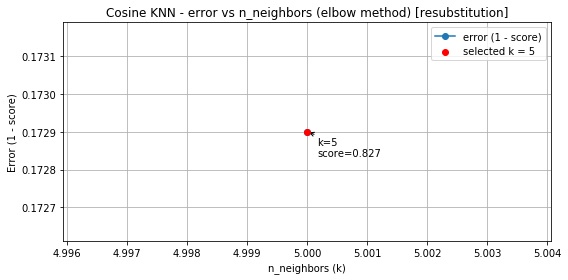

Reference model built with k=5 clusters.


In [41]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
knn_final, cv_scores, best_k =  build_reference_knn_elbow_cosine(df, leave_out_program=leave_out_program, k_min=5, k_max=5)

print(f"Reference model built with k={best_k} clusters.")

In [42]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    knn=knn_final
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",0
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",0
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",0
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",0
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1


In [14]:
from sklearn.metrics import recall_score
import numpy as np

In [15]:
def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [43]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.489247311827957}


In [40]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.10714285714285714}


In [37]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.7729257641921398}


In [34]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.017857142857142856}


In [31]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.0}


In [28]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.8210526315789474}


In [25]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.6423076923076924}


In [22]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.08152173913043478}


In [19]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.6167664670658682}


In [16]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.37254901960784315}


In [44]:
import numpy as np

values = [0.489247311827957, 0.10714285714285714, 0.7729257641921398, 0.017857142857142856, 0.0,  0.8210526315789474, 0.6423076923076924, 0.08152173913043478, 0.6167664670658682, 0.37254901960784315]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.39213706257108827
Std: 0.30387282147811456


## Cluster functions Test 2 (with database) KNN + Majority Closer Points (k=1)

In [73]:
from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
import warnings
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_is_fitted

In [74]:
def build_reference_knn_elbow_cosine(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 1,
    k_max: int = 10,
    validation_frac: float = 0.0,
    random_state: int = 0,
    n_jobs: int = -1,
    scoring_on: str = "accuracy",
    elbow_tol: float = 1e-8
) -> Tuple[KNeighborsClassifier, Dict[int, float], int]:
    """
    Build a k-NN classifier (using COSINE distance) excluding `leave_out_program`
    and choose k using the Elbow / "knee" method on the error curve.

    By default this uses *resubstitution error* (train and test on the same ref set)
    which is fast but optimistic. To use a single hold-out for evaluation set
    validation_frac in (0,1) (e.g. 0.2).

    Returns:
      knn_final: fitted KNeighborsClassifier(metric='cosine', algorithm='brute')
      cv_scores: dict mapping n_neighbors -> mean score (higher is better)
      best_k: selected k by elbow method
    """
    # required columns
    required_cols = {'program', 'embeddings', 'label'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"DataFrame must contain columns: {missing}")

    # reference set
    ref = df[df['program'] != leave_out_program].copy()
    if ref.shape[0] == 0:
        raise ValueError(f"No reference rows left after excluding program '{leave_out_program}'")

    # stack embeddings robustly
    try:
        X_ref = np.vstack(ref['embeddings'].values)
    except Exception as e:
        raise ValueError("Could not stack embeddings — ensure each 'embeddings' entry is array-like of the same length.") from e
    y_ref = ref['label'].astype(int).values
    n_samples = X_ref.shape[0]
    print(f"Reference dataset: {n_samples} entries (excluding '{leave_out_program}').")

    # k range
    max_possible_k = max(1, n_samples - 1)
    max_k = min(k_max, max_possible_k)
    if max_k < k_min:
        raise ValueError(f"k_min={k_min} is too large for the reference size (max allowed is {max_k}).")
    ks = list(range(k_min, max_k + 1))

    # If validation_frac provided, create a single stratified split
    use_validation = False
    if validation_frac is not None and 0.0 < validation_frac < 1.0:
        if len(np.unique(y_ref)) < 2:
            warnings.warn("Less than two classes in reference; validation split ignored.")
        else:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=validation_frac, random_state=random_state)
            train_idx, val_idx = next(sss.split(X_ref, y_ref))
            X_train_eval, X_val = X_ref[train_idx], X_ref[val_idx]
            y_train_eval, y_val = y_ref[train_idx], y_ref[val_idx]
            use_validation = True

    # compute score for each k (no cross-validation here)
    scores: Dict[int, float] = {}
    for k in ks:
        # cosine distance requires brute-force algorithm in sklearn
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
        if use_validation:
            # train on train_eval, evaluate on held-out validation
            knn_tmp.fit(X_train_eval, y_train_eval)
            score = knn_tmp.score(X_val, y_val)  # accuracy by default
        else:
            # resubstitution: train and test on full reference set (optimistic)
            knn_tmp.fit(X_ref, y_ref)
            score = knn_tmp.score(X_ref, y_ref)
        scores[k] = float(score)

    # convert to error curve (assuming score in [0,1], larger is better)
    ks_arr = np.array(ks, dtype=float)
    errors = np.array([1.0 - scores[k] for k in ks], dtype=float)

    # elbow detection
    if len(ks_arr) == 1:
        best_k = int(ks_arr[0])
        print(f"Only one k to evaluate. Selected k = {best_k}.")
    else:
        x1, y1 = ks_arr[0], errors[0]
        x2, y2 = ks_arr[-1], errors[-1]
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom <= elbow_tol:
            # degenerate -> pick best score (tie-breaker: smallest k)
            best_score = max(scores.values())
            best_candidates = [k for k, v in scores.items() if v == best_score]
            best_k = min(best_candidates)
            print("Elbow detection degenerate (endpoints nearly identical). Falling back to best-score selection.")
        else:
            numerators = np.abs((y2 - y1) * ks_arr - (x2 - x1) * errors + x2 * y1 - y2 * x1)
            distances = numerators / denom
            max_idx = int(np.argmax(distances))
            best_k_candidate = int(ks_arr[max_idx])
            max_dist = distances[max_idx]
            if max_dist <= elbow_tol:
                best_score = max(scores.values())
                best_candidates = [k for k, v in scores.items() if v == best_score]
                best_k = min(best_candidates)
                print("No pronounced elbow detected (max distance tiny). Falling back to best-score selection.")
            else:
                best_k = best_k_candidate
                print(f"Elbow detected at k = {best_k} (max perpendicular distance = {max_dist:.6g}).")

    # fit final model on full reference set using cosine distance
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
    knn_final.fit(X_ref, y_ref)

    # plot error curve and mark selection
    plt.figure(figsize=(8, 4))
    plt.plot(ks_arr, errors, marker='o', label='error (1 - score)')
    plt.scatter([best_k], [1.0 - scores[best_k]], color='red', zorder=5, label=f'selected k = {best_k}')
    plt.annotate(f"k={best_k}\nscore={scores[best_k]:.3f}",
                 xy=(best_k, 1.0 - scores[best_k]),
                 xytext=(10, -25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    plt.title(f"Cosine KNN - error vs n_neighbors (elbow method) [{'validation' if use_validation else 'resubstitution'}]")
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Error (1 - score)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return knn_final, scores, best_k

In [75]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    knn: KNeighborsClassifier,
    return_proba: bool = False,
    proba_col: str = "predicted_proba"
) -> pd.DataFrame:
    """
    Classify entries of `program_name` using a trained KNN classifier.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with at least 'program' and 'embeddings' columns.
    program_name : str
        Program to classify.
    knn : KNeighborsClassifier
        Trained KNN classifier on reference data (must be fitted).
    return_proba : bool
        If True and the classifier supports predict_proba, adds `proba_col` column
        with the maximum predicted probability per row (float in [0,1]).
    proba_col : str
        Column name to store predicted probability (when return_proba is True).

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with new column(s):
        - 'predicted_label': predicted label from KNN classifier
        - optionally `proba_col` with float max probability (if available & requested)
    """
    # 1) Filter and basic checks
    if 'program' not in df.columns or 'embeddings' not in df.columns:
        raise ValueError("DataFrame must contain 'program' and 'embeddings' columns.")

    test_df = df.loc[df['program'] == program_name].copy()
    if test_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    # 2) Check that KNN is fitted
    try:
        check_is_fitted(knn)
    except Exception as e:
        raise ValueError("Provided `knn` does not appear to be fitted. Call `.fit()` first.") from e

    # 3) Prepare X_test robustly
    try:
        # Convert to array-like and stack. This handles lists/1D arrays/ndarrays.
        emb_list = list(test_df['embeddings'].values)
        X_test = np.stack([np.asarray(e) for e in emb_list], axis=0)
    except Exception as exc:
        # Provide a helpful error message
        raise ValueError(
            "Error preparing embeddings for prediction. Ensure each 'embeddings' entry "
            "is array-like of the same length. Original error: " + str(exc)
        ) from exc

    # 4) Predict labels
    try:
        # "Classification is computed from a simple majority vote of the nearest neighbors of each point"
        # See link https://scikit-learn.org/stable/modules/neighbors.html
        predicted_labels = knn.predict(X_test)
    except Exception as exc:
        raise RuntimeError("Error during knn.predict: " + str(exc)) from exc

    test_df['predicted_label'] = predicted_labels

    # 5) Optionally add predicted probability/confidence
    if return_proba:
        if hasattr(knn, "predict_proba"):
            try:
                probs = knn.predict_proba(X_test)  # shape (n_samples, n_classes)
                # store the max class probability as a simple confidence scalar
                max_probs = probs.max(axis=1)
                test_df[proba_col] = max_probs
            except Exception as exc:
                # If predict_proba exists but fails, warn / raise as appropriate
                raise RuntimeError("Error during knn.predict_proba: " + str(exc)) from exc
        else:
            raise ValueError("The provided KNN classifier does not support `predict_proba`. "
                             "Train with `probability=True` (or use a classifier that supports it).")

    # 6) Reset index for clarity and return
    test_df.reset_index(drop=True, inplace=True)
    return test_df

In [76]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Only one k to evaluate. Selected k = 1.


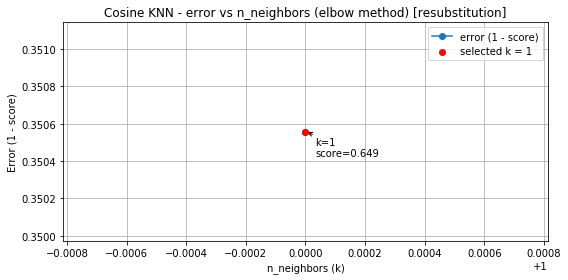

Reference model built with k=1 clusters.


In [105]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
knn_final, cv_scores, best_k =  build_reference_knn_elbow_cosine(df, leave_out_program=leave_out_program, k_min=1, k_max=1)

print(f"Reference model built with k={best_k} clusters.")

In [106]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    knn=knn_final
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",0
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",1
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",1
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",1
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1


In [77]:
def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [80]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.5098039215686274}


In [83]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.7934131736526946}


In [86]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.6086956521739131}


In [89]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.75}


In [92]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.8947368421052632}


In [95]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.7241379310344828}


In [98]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.625}


In [101]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.8864628820960698}


In [104]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.7142857142857143}


In [107]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.7867383512544803}


In [81]:
import numpy as np

values = [0.50, 0.79, 0.60, 0.75, 0.89, 0.72, 0.62, 0.88, 0.71, 0.78]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.724
Std: 0.11689311356961966


## Cluster functions Test 2 (with database) KNN + Majority Closer Points (k=3)

In [82]:
from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
import warnings
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_is_fitted

In [83]:
def build_reference_knn_elbow_cosine(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 1,
    k_max: int = 10,
    validation_frac: float = 0.0,
    random_state: int = 0,
    n_jobs: int = -1,
    scoring_on: str = "accuracy",
    elbow_tol: float = 1e-8
) -> Tuple[KNeighborsClassifier, Dict[int, float], int]:
    """
    Build a k-NN classifier (using COSINE distance) excluding `leave_out_program`
    and choose k using the Elbow / "knee" method on the error curve.

    By default this uses *resubstitution error* (train and test on the same ref set)
    which is fast but optimistic. To use a single hold-out for evaluation set
    validation_frac in (0,1) (e.g. 0.2).

    Returns:
      knn_final: fitted KNeighborsClassifier(metric='cosine', algorithm='brute')
      cv_scores: dict mapping n_neighbors -> mean score (higher is better)
      best_k: selected k by elbow method
    """
    # required columns
    required_cols = {'program', 'embeddings', 'label'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"DataFrame must contain columns: {missing}")

    # reference set
    ref = df[df['program'] != leave_out_program].copy()
    if ref.shape[0] == 0:
        raise ValueError(f"No reference rows left after excluding program '{leave_out_program}'")

    # stack embeddings robustly
    try:
        X_ref = np.vstack(ref['embeddings'].values)
    except Exception as e:
        raise ValueError("Could not stack embeddings — ensure each 'embeddings' entry is array-like of the same length.") from e
    y_ref = ref['label'].astype(int).values
    n_samples = X_ref.shape[0]
    print(f"Reference dataset: {n_samples} entries (excluding '{leave_out_program}').")

    # k range
    max_possible_k = max(1, n_samples - 1)
    max_k = min(k_max, max_possible_k)
    if max_k < k_min:
        raise ValueError(f"k_min={k_min} is too large for the reference size (max allowed is {max_k}).")
    ks = list(range(k_min, max_k + 1))

    # If validation_frac provided, create a single stratified split
    use_validation = False
    if validation_frac is not None and 0.0 < validation_frac < 1.0:
        if len(np.unique(y_ref)) < 2:
            warnings.warn("Less than two classes in reference; validation split ignored.")
        else:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=validation_frac, random_state=random_state)
            train_idx, val_idx = next(sss.split(X_ref, y_ref))
            X_train_eval, X_val = X_ref[train_idx], X_ref[val_idx]
            y_train_eval, y_val = y_ref[train_idx], y_ref[val_idx]
            use_validation = True

    # compute score for each k (no cross-validation here)
    scores: Dict[int, float] = {}
    for k in ks:
        # cosine distance requires brute-force algorithm in sklearn
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
        if use_validation:
            # train on train_eval, evaluate on held-out validation
            knn_tmp.fit(X_train_eval, y_train_eval)
            score = knn_tmp.score(X_val, y_val)  # accuracy by default
        else:
            # resubstitution: train and test on full reference set (optimistic)
            knn_tmp.fit(X_ref, y_ref)
            score = knn_tmp.score(X_ref, y_ref)
        scores[k] = float(score)

    # convert to error curve (assuming score in [0,1], larger is better)
    ks_arr = np.array(ks, dtype=float)
    errors = np.array([1.0 - scores[k] for k in ks], dtype=float)

    # elbow detection
    if len(ks_arr) == 1:
        best_k = int(ks_arr[0])
        print(f"Only one k to evaluate. Selected k = {best_k}.")
    else:
        x1, y1 = ks_arr[0], errors[0]
        x2, y2 = ks_arr[-1], errors[-1]
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom <= elbow_tol:
            # degenerate -> pick best score (tie-breaker: smallest k)
            best_score = max(scores.values())
            best_candidates = [k for k, v in scores.items() if v == best_score]
            best_k = min(best_candidates)
            print("Elbow detection degenerate (endpoints nearly identical). Falling back to best-score selection.")
        else:
            numerators = np.abs((y2 - y1) * ks_arr - (x2 - x1) * errors + x2 * y1 - y2 * x1)
            distances = numerators / denom
            max_idx = int(np.argmax(distances))
            best_k_candidate = int(ks_arr[max_idx])
            max_dist = distances[max_idx]
            if max_dist <= elbow_tol:
                best_score = max(scores.values())
                best_candidates = [k for k, v in scores.items() if v == best_score]
                best_k = min(best_candidates)
                print("No pronounced elbow detected (max distance tiny). Falling back to best-score selection.")
            else:
                best_k = best_k_candidate
                print(f"Elbow detected at k = {best_k} (max perpendicular distance = {max_dist:.6g}).")

    # fit final model on full reference set using cosine distance
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
    knn_final.fit(X_ref, y_ref)

    # plot error curve and mark selection
    plt.figure(figsize=(8, 4))
    plt.plot(ks_arr, errors, marker='o', label='error (1 - score)')
    plt.scatter([best_k], [1.0 - scores[best_k]], color='red', zorder=5, label=f'selected k = {best_k}')
    plt.annotate(f"k={best_k}\nscore={scores[best_k]:.3f}",
                 xy=(best_k, 1.0 - scores[best_k]),
                 xytext=(10, -25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    plt.title(f"Cosine KNN - error vs n_neighbors (elbow method) [{'validation' if use_validation else 'resubstitution'}]")
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Error (1 - score)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return knn_final, scores, best_k

In [84]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    knn: KNeighborsClassifier,
    return_proba: bool = False,
    proba_col: str = "predicted_proba"
) -> pd.DataFrame:
    """
    Classify entries of `program_name` using a trained KNN classifier.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with at least 'program' and 'embeddings' columns.
    program_name : str
        Program to classify.
    knn : KNeighborsClassifier
        Trained KNN classifier on reference data (must be fitted).
    return_proba : bool
        If True and the classifier supports predict_proba, adds `proba_col` column
        with the maximum predicted probability per row (float in [0,1]).
    proba_col : str
        Column name to store predicted probability (when return_proba is True).

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with new column(s):
        - 'predicted_label': predicted label from KNN classifier
        - optionally `proba_col` with float max probability (if available & requested)
    """
    # 1) Filter and basic checks
    if 'program' not in df.columns or 'embeddings' not in df.columns:
        raise ValueError("DataFrame must contain 'program' and 'embeddings' columns.")

    test_df = df.loc[df['program'] == program_name].copy()
    if test_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    # 2) Check that KNN is fitted
    try:
        check_is_fitted(knn)
    except Exception as e:
        raise ValueError("Provided `knn` does not appear to be fitted. Call `.fit()` first.") from e

    # 3) Prepare X_test robustly
    try:
        # Convert to array-like and stack. This handles lists/1D arrays/ndarrays.
        emb_list = list(test_df['embeddings'].values)
        X_test = np.stack([np.asarray(e) for e in emb_list], axis=0)
    except Exception as exc:
        # Provide a helpful error message
        raise ValueError(
            "Error preparing embeddings for prediction. Ensure each 'embeddings' entry "
            "is array-like of the same length. Original error: " + str(exc)
        ) from exc

    # 4) Predict labels
    try:
        # "Classification is computed from a simple majority vote of the nearest neighbors of each point"
        # See link https://scikit-learn.org/stable/modules/neighbors.html
        predicted_labels = knn.predict(X_test)
    except Exception as exc:
        raise RuntimeError("Error during knn.predict: " + str(exc)) from exc

    test_df['predicted_label'] = predicted_labels

    # 5) Optionally add predicted probability/confidence
    if return_proba:
        if hasattr(knn, "predict_proba"):
            try:
                probs = knn.predict_proba(X_test)  # shape (n_samples, n_classes)
                # store the max class probability as a simple confidence scalar
                max_probs = probs.max(axis=1)
                test_df[proba_col] = max_probs
            except Exception as exc:
                # If predict_proba exists but fails, warn / raise as appropriate
                raise RuntimeError("Error during knn.predict_proba: " + str(exc)) from exc
        else:
            raise ValueError("The provided KNN classifier does not support `predict_proba`. "
                             "Train with `probability=True` (or use a classifier that supports it).")

    # 6) Reset index for clarity and return
    test_df.reset_index(drop=True, inplace=True)
    return test_df

In [85]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Only one k to evaluate. Selected k = 3.


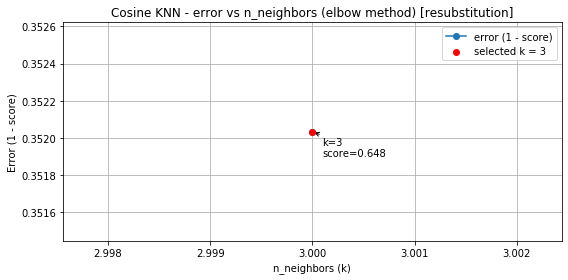

Reference model built with k=3 clusters.


In [115]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
knn_final, cv_scores, best_k =  build_reference_knn_elbow_cosine(df, leave_out_program=leave_out_program, k_min=3, k_max=3)

print(f"Reference model built with k={best_k} clusters.")

In [116]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    knn=knn_final
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",0
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",0
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",1
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",1
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1


In [104]:
from sklearn.metrics import recall_score
import numpy as np

def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [89]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.4852941176470588}


In [92]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.7694610778443114}


In [95]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.5543478260869565}


In [98]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.7653846153846153}


In [101]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.9052631578947369}


In [105]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.7241379310344828}


In [108]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.625}


In [111]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.8820960698689956}


In [114]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.7142857142857143}


In [117]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.7813620071684588}


In [118]:
import numpy as np

values = [0.48, 0.76, 0.55, 0.76,  0.90, 0.72, 0.62, 0.88, 0.71,  0.78 ]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.716
Std: 0.12698031343479982


## Cluster functions Test 2 (with database) KNN + Majority Closer Points (k=15)

In [119]:
from typing import Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
import warnings
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_is_fitted

In [120]:
def build_reference_knn_elbow_cosine(
    df: pd.DataFrame,
    leave_out_program: str,
    k_min: int = 1,
    k_max: int = 10,
    validation_frac: float = 0.0,
    random_state: int = 0,
    n_jobs: int = -1,
    scoring_on: str = "accuracy",
    elbow_tol: float = 1e-8
) -> Tuple[KNeighborsClassifier, Dict[int, float], int]:
    """
    Build a k-NN classifier (using COSINE distance) excluding `leave_out_program`
    and choose k using the Elbow / "knee" method on the error curve.

    By default this uses *resubstitution error* (train and test on the same ref set)
    which is fast but optimistic. To use a single hold-out for evaluation set
    validation_frac in (0,1) (e.g. 0.2).

    Returns:
      knn_final: fitted KNeighborsClassifier(metric='cosine', algorithm='brute')
      cv_scores: dict mapping n_neighbors -> mean score (higher is better)
      best_k: selected k by elbow method
    """
    # required columns
    required_cols = {'program', 'embeddings', 'label'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"DataFrame must contain columns: {missing}")

    # reference set
    ref = df[df['program'] != leave_out_program].copy()
    if ref.shape[0] == 0:
        raise ValueError(f"No reference rows left after excluding program '{leave_out_program}'")

    # stack embeddings robustly
    try:
        X_ref = np.vstack(ref['embeddings'].values)
    except Exception as e:
        raise ValueError("Could not stack embeddings — ensure each 'embeddings' entry is array-like of the same length.") from e
    y_ref = ref['label'].astype(int).values
    n_samples = X_ref.shape[0]
    print(f"Reference dataset: {n_samples} entries (excluding '{leave_out_program}').")

    # k range
    max_possible_k = max(1, n_samples - 1)
    max_k = min(k_max, max_possible_k)
    if max_k < k_min:
        raise ValueError(f"k_min={k_min} is too large for the reference size (max allowed is {max_k}).")
    ks = list(range(k_min, max_k + 1))

    # If validation_frac provided, create a single stratified split
    use_validation = False
    if validation_frac is not None and 0.0 < validation_frac < 1.0:
        if len(np.unique(y_ref)) < 2:
            warnings.warn("Less than two classes in reference; validation split ignored.")
        else:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=validation_frac, random_state=random_state)
            train_idx, val_idx = next(sss.split(X_ref, y_ref))
            X_train_eval, X_val = X_ref[train_idx], X_ref[val_idx]
            y_train_eval, y_val = y_ref[train_idx], y_ref[val_idx]
            use_validation = True

    # compute score for each k (no cross-validation here)
    scores: Dict[int, float] = {}
    for k in ks:
        # cosine distance requires brute-force algorithm in sklearn
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
        if use_validation:
            # train on train_eval, evaluate on held-out validation
            knn_tmp.fit(X_train_eval, y_train_eval)
            score = knn_tmp.score(X_val, y_val)  # accuracy by default
        else:
            # resubstitution: train and test on full reference set (optimistic)
            knn_tmp.fit(X_ref, y_ref)
            score = knn_tmp.score(X_ref, y_ref)
        scores[k] = float(score)

    # convert to error curve (assuming score in [0,1], larger is better)
    ks_arr = np.array(ks, dtype=float)
    errors = np.array([1.0 - scores[k] for k in ks], dtype=float)

    # elbow detection
    if len(ks_arr) == 1:
        best_k = int(ks_arr[0])
        print(f"Only one k to evaluate. Selected k = {best_k}.")
    else:
        x1, y1 = ks_arr[0], errors[0]
        x2, y2 = ks_arr[-1], errors[-1]
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom <= elbow_tol:
            # degenerate -> pick best score (tie-breaker: smallest k)
            best_score = max(scores.values())
            best_candidates = [k for k, v in scores.items() if v == best_score]
            best_k = min(best_candidates)
            print("Elbow detection degenerate (endpoints nearly identical). Falling back to best-score selection.")
        else:
            numerators = np.abs((y2 - y1) * ks_arr - (x2 - x1) * errors + x2 * y1 - y2 * x1)
            distances = numerators / denom
            max_idx = int(np.argmax(distances))
            best_k_candidate = int(ks_arr[max_idx])
            max_dist = distances[max_idx]
            if max_dist <= elbow_tol:
                best_score = max(scores.values())
                best_candidates = [k for k, v in scores.items() if v == best_score]
                best_k = min(best_candidates)
                print("No pronounced elbow detected (max distance tiny). Falling back to best-score selection.")
            else:
                best_k = best_k_candidate
                print(f"Elbow detected at k = {best_k} (max perpendicular distance = {max_dist:.6g}).")

    # fit final model on full reference set using cosine distance
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=n_jobs)
    knn_final.fit(X_ref, y_ref)

    # plot error curve and mark selection
    plt.figure(figsize=(8, 4))
    plt.plot(ks_arr, errors, marker='o', label='error (1 - score)')
    plt.scatter([best_k], [1.0 - scores[best_k]], color='red', zorder=5, label=f'selected k = {best_k}')
    plt.annotate(f"k={best_k}\nscore={scores[best_k]:.3f}",
                 xy=(best_k, 1.0 - scores[best_k]),
                 xytext=(10, -25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    plt.title(f"Cosine KNN - error vs n_neighbors (elbow method) [{'validation' if use_validation else 'resubstitution'}]")
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Error (1 - score)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return knn_final, scores, best_k

In [121]:
def classify_program_entries(
    df: pd.DataFrame,
    program_name: str,
    knn: KNeighborsClassifier,
    return_proba: bool = False,
    proba_col: str = "predicted_proba"
) -> pd.DataFrame:
    """
    Classify entries of `program_name` using a trained KNN classifier.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with at least 'program' and 'embeddings' columns.
    program_name : str
        Program to classify.
    knn : KNeighborsClassifier
        Trained KNN classifier on reference data (must be fitted).
    return_proba : bool
        If True and the classifier supports predict_proba, adds `proba_col` column
        with the maximum predicted probability per row (float in [0,1]).
    proba_col : str
        Column name to store predicted probability (when return_proba is True).

    Returns
    -------
    pd.DataFrame
        Sub-DataFrame for `program_name` with new column(s):
        - 'predicted_label': predicted label from KNN classifier
        - optionally `proba_col` with float max probability (if available & requested)
    """
    # 1) Filter and basic checks
    if 'program' not in df.columns or 'embeddings' not in df.columns:
        raise ValueError("DataFrame must contain 'program' and 'embeddings' columns.")

    test_df = df.loc[df['program'] == program_name].copy()
    if test_df.empty:
        raise ValueError(f"No entries found for program '{program_name}'")

    # 2) Check that KNN is fitted
    try:
        check_is_fitted(knn)
    except Exception as e:
        raise ValueError("Provided `knn` does not appear to be fitted. Call `.fit()` first.") from e

    # 3) Prepare X_test robustly
    try:
        # Convert to array-like and stack. This handles lists/1D arrays/ndarrays.
        emb_list = list(test_df['embeddings'].values)
        X_test = np.stack([np.asarray(e) for e in emb_list], axis=0)
    except Exception as exc:
        # Provide a helpful error message
        raise ValueError(
            "Error preparing embeddings for prediction. Ensure each 'embeddings' entry "
            "is array-like of the same length. Original error: " + str(exc)
        ) from exc

    # 4) Predict labels
    try:
        # "Classification is computed from a simple majority vote of the nearest neighbors of each point"
        # See link https://scikit-learn.org/stable/modules/neighbors.html
        predicted_labels = knn.predict(X_test)
    except Exception as exc:
        raise RuntimeError("Error during knn.predict: " + str(exc)) from exc

    test_df['predicted_label'] = predicted_labels

    # 5) Optionally add predicted probability/confidence
    if return_proba:
        if hasattr(knn, "predict_proba"):
            try:
                probs = knn.predict_proba(X_test)  # shape (n_samples, n_classes)
                # store the max class probability as a simple confidence scalar
                max_probs = probs.max(axis=1)
                test_df[proba_col] = max_probs
            except Exception as exc:
                # If predict_proba exists but fails, warn / raise as appropriate
                raise RuntimeError("Error during knn.predict_proba: " + str(exc)) from exc
        else:
            raise ValueError("The provided KNN classifier does not support `predict_proba`. "
                             "Train with `probability=True` (or use a classifier that supports it).")

    # 6) Reset index for clarity and return
    test_df.reset_index(drop=True, inplace=True)
    return test_df

In [128]:
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
df.head()

Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']


,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


Reference dataset: 6096 entries (excluding 'packcc').
Only one k to evaluate. Selected k = 15.


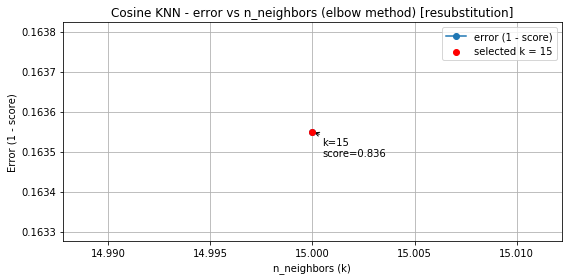

Reference model built with k=15 clusters.


In [153]:
# 1. Build reference on all except the target:
leave_out_program="packcc"
knn_final, cv_scores, best_k =  build_reference_knn_elbow_cosine(df, leave_out_program=leave_out_program, k_min=15, k_max=15)

print(f"Reference model built with k={best_k} clusters.")

In [154]:
# 2. Classify the held-out program’s entries:
results = classify_program_entries(
    df,
    program_name=leave_out_program,
    knn=knn_final
)

# Results DataFrame
results.head()

,name,address,label,program,option,compiler,embeddings,predicted_label
0,sym.replace_fileext,4206672,0,packcc,O1,clang,"[0.1958023756742477, 0.0348879881203174, -0.06...",0
1,sym.refill_buffer,4215840,0,packcc,O1,clang,"[0.1999838203191757, 0.0287446193397045, -0.06...",1
2,sym.match_eol,4215680,1,packcc,O1,clang,"[0.1947075724601745, 0.0554501973092556, -0.05...",0
3,sym.match_section_line_,4216176,1,packcc,O1,clang,"[0.2037548273801803, 0.051951378583908, -0.066...",0
4,sym.parse_directive_include_,4207056,1,packcc,O1,clang,"[0.1999526917934417, 0.0157187897711992, -0.05...",1


In [155]:
from sklearn.metrics import recall_score
import numpy as np

def compute_recall(df, real_col='label', pred_col='predicted_label'):
    """
    Compute recall score between two columns of a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the true and predicted labels.
    real_col : str
        Name of the column in df with the true binary labels (0 or 1).
    pred_col : str
        Name of the column in df with the predicted binary labels (0 or 1).

    Returns
    -------
    dict
        Dictionary containing:
            - recall: Recall Score
    """
    y_true = df[real_col].values
    y_pred = df[pred_col].values

    recall = recall_score(y_true, y_pred)

    return {
        'recall': recall
    }

In [126]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cparserXML'] we have: 
{'recall': 0.3627450980392157}


In [131]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['picohttpparser'] we have: 
{'recall': 0.6077844311377245}


In [134]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['csimpleJSONparser'] we have: 
{'recall': 0.2826086956521739}


In [137]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['cJSON'] we have: 
{'recall': 0.5884615384615385}


In [140]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['benoitc_HTTP'] we have: 
{'recall': 0.8210526315789474}


In [143]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['yacc_calculator'] we have: 
{'recall': 0.6551724137931034}


In [146]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['network_packet_analyzer'] we have: 
{'recall': 0.0}


In [149]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['elf_parser'] we have: 
{'recall': 0.7379912663755459}


In [152]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['pcap_parser'] we have: 
{'recall': 0.0}


In [156]:
# Compute regression metrics for the results DataFrame
metrics = compute_recall(results, 'label', 'predicted_label')
print(f"For the program {results['program'].unique()} we have: \n{metrics}")

For the program ['packcc'] we have: 
{'recall': 0.46953405017921146}


In [157]:
import numpy as np

values = [0.36, 0.60, 0.28, 0.58, 0.82, 0.65, 0.0, 0.73, 0.0, 0.46]
print(f"len: {len(values)}")
print(f"Mean: {np.mean(values)}")
print(f"Std: {np.std(values)}")

len: 10
Mean: 0.44799999999999995
Std: 0.27143323304267664


# SAFETORCH Experiments 2: Training a model on embeddings of functions 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
def load_embeddings(csv_path: str) -> pd.DataFrame:
    """Load SAFE embeddings CSV (expects columns: exe, name, label, emb_0…emb_D)."""
    return pd.read_csv(csv_path)

In [3]:
def parse_filename(fn: str):
    """
    Splits a filename into (executable, option, compiler).
    """
    # Map from filename‐stem prefixes to your canonical program names:
    PREFIX_TO_PROGRAM = {
        "parse_xml": "cparserXML",
        "example":   "csimpleJSONparser",
        "http_parser": "benoitc_HTTP",
        "cjson": "cJSON",
        "picohttpparser": "picohttpparser",
        "calc": "yacc_calculator",
        "elf-parser": "elf_parser",
        "network_analyzer": "network_packet_analyzer",
        "packcc": "packcc",
        "pcap_parser": "pcap_parser",
    }

    # Compilers
    KNOWN_COMPILERS = {'gcc', 'clang'}
    # Optimization tokens
    OPT_TOKEN_MAP = {
        '0': 'O0', '1': 'O1', '2': 'O2', '3': 'O3',
        's': 'Os', 'fast': 'Ofast',
        'O0': 'O0', 'O1': 'O1', 'O2': 'O2', 'O3': 'O3',
        'Os': 'Os', 'Ofast': 'Ofast',
    }
    # strip extension
    stem = fn.rsplit(".", 1)[0]
    
    # find which prefix it starts with
    # take the longest matching key so that "parse_xml" beats "par" if both existed
    candidates = [p for p in PREFIX_TO_PROGRAM if stem.startswith(p)]
    if candidates:
        # pick the longest matching key
        best = max(candidates, key=len)
        program = PREFIX_TO_PROGRAM[best]
        remainder = stem[len(best):].lstrip("_")
    else:
        # fallback: use everything before first underscore
        parts = stem.split("_", 1)
        program = parts[0]
        remainder = parts[1] if len(parts) > 1 else ""
    
    # split off settings tokens
    settings = remainder.split("_") if remainder else []
    
    # compiler: first known compiler in settings, else default gcc
    compiler = next((s for s in settings if s in KNOWN_COMPILERS), "gcc")
    
    # optimization: map tokens via OPT_TOKEN_MAP or keep digits
    opts = []
    for s in settings:
        if s in OPT_TOKEN_MAP:
            opts.append(OPT_TOKEN_MAP[s])
        elif s.isdigit():
            opts.append(s)
    option = "_".join(opts) if opts else "default"
    
    return program, option, compiler

def enrich_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'program', 'option', 'compiler' columns to a DataFrame
    with an existing 'filename' column.
    """
    parsed = df["filename"].apply(parse_filename)
    df = df.copy()
    df[["program", "option", "compiler"]] = pd.DataFrame(parsed.tolist(), index=df.index)
    # Remove the 'filename' column as it's no longer needed
    df.drop(columns=["filename"], inplace=True)
    # Merge the all the embedding columns into a single column
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    df["embeddings"] = df[emb_cols].apply(lambda row: row.tolist(), axis=1)
    # Drop the individual embedding columns
    df.drop(columns=emb_cols, inplace=True)
    return df

In [4]:
path = "../safetorch/outputs/all_function_embeddings.csv"
df = load_embeddings(path)

print(f"Loaded {len(df)} SAFE embeddings (= functions).")
print(f"Columns in DataFrame: {df.columns.tolist()}\n")
print(f"Unique executables (filenames): {df['filename'].unique().tolist()}")


Loaded 7898 SAFE embeddings (= functions).
Columns in DataFrame: ['filename', 'name', 'address', 'label', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_54', 'emb_55', 'emb_56', 'emb_57', 'emb_58', 'emb_59', 'emb_60', 'emb_61', 'emb_62', 'emb_63', 'emb_64', 'emb_65', 'emb_66', 'emb_67', 'emb_68', 'emb_69', 'emb_70', 'emb_71', 'emb_72', 'emb_73', 'emb_74', 'emb_75', 'emb_76', 'emb_77', 'emb_78', 'emb_79', 'emb_80', 'emb_81', 'emb_82', 'emb_83', 'emb_84', 'emb_85', 'emb_86', 'emb_87', 'emb_88', 'emb_89', 'emb

In [5]:
# enrich the DataFrame with program, option, compiler columns
#df = enrich_df(df) 
# Save to a csv file
#df.to_csv("../safetorch/outputs/all_function_embeddings_enriched.csv", index=False)
# Read the csv file
df = pd.read_csv("../safetorch/outputs/all_function_embeddings_enriched.csv")

df.head()

,name,address,label,program,option,compiler,embeddings
0,sym.deregister_tm_clones,134517136,0,cparserXML,O2_32,gcc,"[0.1290605962276458, 0.101205363869667, 0.0727..."
1,sym.register_tm_clones,134517200,0,cparserXML,O2_32,gcc,"[0.1371031105518341, 0.0935542583465576, 0.034..."
2,sym.__do_global_dtors_aux,134517264,0,cparserXML,O2_32,gcc,"[0.1252177506685257, 0.1005747094750404, 0.101..."
3,sym.frame_dummy,134517312,0,cparserXML,O2_32,gcc,"[0.01095861941576, 0.0850951969623565, -0.0760..."
4,sym.parse_parent_element,134517328,1,cparserXML,O2_32,gcc,"[0.1999526917934417, 0.0157187897711992, -0.05..."


In [6]:
# Print dataframe information
print("DataFrame Information:")
print(f"Unique programs (total len {len(df['program'].unique().tolist())}): {df['program'].unique().tolist()}")
print(f"Unique options (total len {len(df['option'].unique().tolist())}): {df['option'].unique().tolist()}")
print(f"Unique compilers: {df['compiler'].unique().tolist()}")

DataFrame Information:
Unique programs (total len 10): ['cparserXML', 'picohttpparser', 'csimpleJSONparser', 'cJSON', 'benoitc_HTTP', 'yacc_calculator', 'network_packet_analyzer', 'elf_parser', 'pcap_parser', 'packcc']
Unique options (total len 14): ['O2_32', 'Ofast_32', 'O0_32', 'O2', 'O1_32', 'Os_32', 'O1', 'O3', 'Ofast', 'O3_32', 'Os', '32', 'default', 'O0']
Unique compilers: ['gcc', 'clang']


## Classify functions Test 1 using XGBoost

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, recall_score
from xgboost import XGBClassifier

In [12]:
def prepare_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure embeddings are numpy arrays."""
    df = df.copy()
    df["embeddings"] = df["embeddings"].apply(
        lambda x: np.array(x) if isinstance(x, list) else np.array(eval(x))
    )
    return df

def train_xgb(X: np.ndarray, y: np.ndarray) -> XGBClassifier:
    """Train an XGBoost classifier."""
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X, y)
    return model

In [13]:
def evaluate_model(model: XGBClassifier, X: np.ndarray, y: np.ndarray, program: str):
    """Evaluate model performance, return predictions and metrics."""
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if model.n_classes_ == 2 else None

    recall = recall_score(y, y_pred, average="binary" if len(np.unique(y)) == 2 else "macro")
    auc = roc_auc_score(y, y_proba) if y_proba is not None else np.nan

    print(f"Program: {program:20s} | Recall: {recall:.4f} | AUC: {auc:.4f}")
    return y_pred, recall, auc

def leave_one_program_out(df: pd.DataFrame) -> pd.DataFrame:
    """Perform leave-one-program-out training and evaluation."""
    df = prepare_embeddings(df)
    df["pred_label"] = -1
    results = []

    for prog in df["program"].unique():
        train_df = df[df["program"] != prog]
        test_df = df[df["program"] == prog]

        X_train = np.vstack(train_df["embeddings"].values)
        y_train = train_df["label"].values

        X_test = np.vstack(test_df["embeddings"].values)
        y_test = test_df["label"].values

        model = train_xgb(X_train, y_train)
        y_pred, recall, auc = evaluate_model(model, X_test, y_test, prog)

        df.loc[df["program"] == prog, "pred_label"] = y_pred
        results.append({"program": prog, "recall": recall, "auc": auc})

    results_df = pd.DataFrame(results)
    return df, results_df

In [15]:
# Run the leave-one-program-out evaluation
df_with_preds, results_df = leave_one_program_out(df)

print("\n=== Results Summary ===")
print(results_df)

print("\nAverage Recall: {:.4f} ± {:.4f}".format(
    results_df["recall"].mean(), results_df["recall"].std()
))
print("Average AUC:    {:.4f} ± {:.4f}".format(
    results_df["auc"].mean(), results_df["auc"].std()
))

Program: cparserXML           | Recall: 0.3627 | AUC: 0.9446
Program: picohttpparser       | Recall: 0.5898 | AUC: 0.8531
Program: csimpleJSONparser    | Recall: 0.2772 | AUC: 0.7735
Program: cJSON                | Recall: 0.5923 | AUC: 0.8161
Program: benoitc_HTTP         | Recall: 0.8211 | AUC: 0.9310
Program: yacc_calculator      | Recall: 0.6552 | AUC: 0.7032
Program: network_packet_analyzer | Recall: 0.0000 | AUC: 0.5466
Program: elf_parser           | Recall: 0.7467 | AUC: 0.7094
Program: pcap_parser          | Recall: 0.0000 | AUC: 0.8253
Program: packcc               | Recall: 0.4839 | AUC: 0.6105

=== Results Summary ===
                   program    recall       auc
0               cparserXML  0.362745  0.944620
1           picohttpparser  0.589820  0.853083
2        csimpleJSONparser  0.277174  0.773535
3                    cJSON  0.592308  0.816098
4             benoitc_HTTP  0.821053  0.930965
5          yacc_calculator  0.655172  0.703185
6  network_packet_analyzer  0.000

## Classify functions Test 1 using XGBoost with Hyperparameter Tuning

In [21]:
import numpy as np
import pandas as pd
import warnings
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut

In [22]:
def prepare_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure embeddings are numpy arrays."""
    df = df.copy()
    df["embeddings"] = df["embeddings"].apply(
        lambda x: np.array(x) if isinstance(x, list) else np.array(eval(x))
    )
    return df

In [ ]:
def find_best_params_across_programs(df: pd.DataFrame, param_grid: dict = None) -> dict:
    """
    Run GridSearchCV once across programs using LeaveOneGroupOut to return a single best param set.
    """
    df = prepare_embeddings(df)
    X = np.vstack(df["embeddings"].values)
    y = df["label"].values
    groups = df["program"].values

    is_binary = len(np.unique(y)) == 2
    scorer = make_scorer(recall_score, average="binary" if is_binary else "macro", zero_division=0)

    base_model = XGBClassifier(eval_metric="logloss", random_state=42)

    if param_grid is None:
        # small default grid — enlarge if you want more thorough search (but it will be slower).
        param_grid = {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.01, 0.1],
        }

    cv = LeaveOneGroupOut()
    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    # Fit with groups to avoid leakage across programs:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        grid.fit(X, y, groups=groups)

    print("Global best params (from group CV):", grid.best_params_)
    return grid.best_params_

def evaluate_model(model: XGBClassifier, X: np.ndarray, y: np.ndarray, program: str):
    """Evaluate model performance, return predictions and metrics (robust to single-class tests)."""
    if X.shape[0] == 0:
        return np.array([]), np.nan, np.nan

    y_pred = model.predict(X)

    # get probability for the 'positive' class if binary
    y_proba = None
    if hasattr(model, "classes_") and len(model.classes_) == 2:
        # find index of positive class (prefer 1 if present)
        classes = list(model.classes_)
        pos = 1 if 1 in classes else classes[1]
        idx = classes.index(pos)
        try:
            y_proba = model.predict_proba(X)[:, idx]
        except Exception:
            y_proba = None

    # choose recall averaging strategy depending on test labels
    avg = "binary" if len(np.unique(y)) == 2 else "macro"
    try:
        recall = recall_score(y, y_pred, average=avg, zero_division=0)
    except Exception:
        recall = np.nan

    auc = np.nan
    if y_proba is not None and len(np.unique(y)) == 2:
        try:
            auc = roc_auc_score(y, y_proba)
        except Exception:
            auc = np.nan

    print(f"Program: {program:20s} | Recall: {recall:.4f} | AUC: {auc:.4f}")
    return y_pred, recall, auc

In [24]:
def leave_one_program_out(df: pd.DataFrame, best_params: dict) -> (pd.DataFrame, pd.DataFrame):
    """
    Perform leave-one-program-out training and evaluation using a single best_params dict.
    """
    df = prepare_embeddings(df)
    df["pred_label"] = -1
    results = []

    for prog in df["program"].unique():
        train_df = df[df["program"] != prog]
        test_df = df[df["program"] == prog]

        X_train = np.vstack(train_df["embeddings"].values)
        y_train = train_df["label"].values

        X_test = np.vstack(test_df["embeddings"].values)
        y_test = test_df["label"].values

        model = XGBClassifier(eval_metric="logloss", random_state=42, **best_params)
        model.fit(X_train, y_train)

        y_pred, recall, auc = evaluate_model(model, X_test, y_test, prog)

        df.loc[df["program"] == prog, "pred_label"] = y_pred
        results.append({"program": prog, "recall": recall, "auc": auc})

    results_df = pd.DataFrame(results)
    return df, results_df


In [ ]:
# 1) Find a single best param set across programs (group-aware CV)
param_grid = {
    "n_estimators": [25, 50, 100],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1],
}
best_params = find_best_params_across_programs(df, param_grid=param_grid)

# 2) Run leave-one-program-out evaluation using the global best_params
df_with_preds, results_df = leave_one_program_out(df, best_params)

print("\n=== Results Summary ===")
print(results_df)

print("\nAverage Recall: {:.4f} ± {:.4f}".format(
    results_df["recall"].mean(), results_df["recall"].std()
))
print("Average AUC:    {:.4f} ± {:.4f}".format(
    results_df["auc"].mean(), results_df["auc"].std()
))

# Optional: print global best params
print("\nGlobal best params used for all folds:", best_params)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
Global best params (from group CV): {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 50}
Program: cparserXML           | Recall: 0.3627 | AUC: 0.9475
Program: picohttpparser       | Recall: 0.6198 | AUC: 0.8553
Program: csimpleJSONparser    | Recall: 0.2772 | AUC: 0.7747
Program: cJSON                | Recall: 0.6000 | AUC: 0.8147
Program: benoitc_HTTP         | Recall: 0.8211 | AUC: 0.9319
Program: yacc_calculator      | Recall: 0.6552 | AUC: 0.7044
Program: network_packet_analyzer | Recall: 0.0000 | AUC: 0.5443
Program: elf_parser           | Recall: 0.7467 | AUC: 0.7112
Program: pcap_parser          | Recall: 0.0000 | AUC: 0.8269
Program: packcc               | Recall: 0.4749 | AUC: 0.6111

=== Results Summary ===
                   program    recall       auc
0               cparserXML  0.362745  0.947537
1           picohttpparser  0.619760  0.855332
2        csimpleJSONparser  0.277174  0.774677
3              

## Classify functions Test 2 using a baseline NN model

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# -------------------------------
# Neural Network Classifier (NNC)
# -------------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)   # binary classification
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.sigmoid(x)

In [18]:
# -------------------------------
# Training function
# -------------------------------
def train_nn(X_train, y_train, input_dim, epochs=20, batch_size=64, lr=1e-3):
    model = SimpleNN(input_dim)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                            torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    return model

In [19]:
# -------------------------------
# Evaluation function
# -------------------------------
def evaluate_nn(model, X, y, program):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        y_proba = model(X_tensor).numpy().flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    recall = recall_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)

    print(f"Program: {program:20s} | Recall: {recall:.4f} | AUC: {auc:.4f}")
    return y_pred, recall, auc

# -------------------------------
# Leave-one-program-out with NN
# -------------------------------
def leave_one_program_out_nn(df: pd.DataFrame):
    df = df.copy()
    df["embeddings"] = df["embeddings"].apply(
        lambda x: np.array(x) if isinstance(x, list) else np.array(eval(x))
    )
    df["pred_label"] = -1
    results = []

    for prog in df["program"].unique():
        train_df = df[df["program"] != prog]
        test_df  = df[df["program"] == prog]

        X_train = np.vstack(train_df["embeddings"].values)
        y_train = train_df["label"].values

        X_test = np.vstack(test_df["embeddings"].values)
        y_test = test_df["label"].values

        input_dim = X_train.shape[1]
        model = train_nn(X_train, y_train, input_dim)

        y_pred, recall, auc = evaluate_nn(model, X_test, y_test, prog)
        df.loc[df["program"] == prog, "pred_label"] = y_pred
        results.append({"program": prog, "recall": recall, "auc": auc})

    results_df = pd.DataFrame(results)
    return df, results_df

In [20]:
df_with_preds, results_df = leave_one_program_out_nn(df)

print("\n=== Results Summary ===")
print(results_df)
print("\nAverage Recall: {:.4f} ± {:.4f}".format(
    results_df["recall"].mean(), results_df["recall"].std()
))
print("Average AUC:    {:.4f} ± {:.4f}".format(
    results_df["auc"].mean(), results_df["auc"].std()
))

Program: cparserXML           | Recall: 0.3627 | AUC: 0.9456
Program: picohttpparser       | Recall: 0.5329 | AUC: 0.8782
Program: csimpleJSONparser    | Recall: 0.1793 | AUC: 0.8167
Program: cJSON                | Recall: 0.6038 | AUC: 0.8687
Program: benoitc_HTTP         | Recall: 0.7579 | AUC: 0.9169
Program: yacc_calculator      | Recall: 0.6552 | AUC: 0.6889
Program: network_packet_analyzer | Recall: 0.0000 | AUC: 0.5530
Program: elf_parser           | Recall: 0.7817 | AUC: 0.7580
Program: pcap_parser          | Recall: 0.0000 | AUC: 0.9139
Program: packcc               | Recall: 0.4409 | AUC: 0.6614

=== Results Summary ===
                   program    recall       auc
0               cparserXML  0.362745  0.945644
1           picohttpparser  0.532934  0.878244
2        csimpleJSONparser  0.179348  0.816706
3                    cJSON  0.603846  0.868739
4             benoitc_HTTP  0.757895  0.916887
5          yacc_calculator  0.655172  0.688882
6  network_packet_analyzer  0.000

## Classify functions Test 2 using a baseline NN model + GridSearch for hyperparameters tuning

In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [34]:
# -------------------------------
# Neural Network Classifier (NNC)
# -------------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.0):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)

In [35]:
# -------------------------------
# Training function
# -------------------------------
def train_nn(X_train, y_train, input_dim, hidden_dim=128, dropout=0.0,
             epochs=20, batch_size=64, lr=1e-3):
    model = SimpleNN(input_dim, hidden_dim, dropout)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                            torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    return model

In [36]:
# -------------------------------
# Evaluation function
# -------------------------------
def evaluate_nn(model, X, y):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        y_proba = model(X_tensor).numpy().flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    recall = recall_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)
    return recall, auc, y_pred

# -------------------------------
# Leave-one-program-out evaluation with fixed hyperparams
# -------------------------------
def leave_one_program_out_fixed(df: pd.DataFrame, hidden_dim=128, dropout=0.0,
                                epochs=20, batch_size=64, lr=1e-3):
    df = df.copy()
    df["embeddings"] = df["embeddings"].apply(
        lambda x: np.array(x) if isinstance(x, list) else np.array(eval(x))
    )
    df["pred_label"] = -1
    results = []

    for prog in df["program"].unique():
        train_df = df[df["program"] != prog]
        test_df  = df[df["program"] == prog]

        X_train = np.vstack(train_df["embeddings"].values)
        y_train = train_df["label"].values

        X_test = np.vstack(test_df["embeddings"].values)
        y_test = test_df["label"].values

        input_dim = X_train.shape[1]
        model = train_nn(X_train, y_train, input_dim,
                         hidden_dim=hidden_dim, dropout=dropout,
                         epochs=epochs, batch_size=batch_size, lr=lr)

        recall, auc, y_pred = evaluate_nn(model, X_test, y_test)
        df.loc[df["program"] == prog, "pred_label"] = y_pred
        results.append({"program": prog, "recall": recall, "auc": auc})

    results_df = pd.DataFrame(results)
    mean_recall = results_df["recall"].mean()
    mean_auc = results_df["auc"].mean()
    return df, results_df, mean_recall, mean_auc

# -------------------------------
# Global Grid Search over hyperparams
# -------------------------------
def global_gridsearch_nn(df: pd.DataFrame):
    param_grid = {
        "hidden_dim": [16, 32, 64],
        "dropout": [0.0, 0.01, 0.1],
        "epochs": [10, 25],
        "batch_size": [32, 64],
        "lr": [0.01, 0.1]
    }

    best_score = -1
    best_params = None
    best_results_df = None
    best_df = None

    for hidden_dim in param_grid["hidden_dim"]:
        for dropout in param_grid["dropout"]:
            for epochs in param_grid["epochs"]:
                for batch_size in param_grid["batch_size"]:
                    for lr in param_grid["lr"]:
                        _, results_df, mean_recall, mean_auc = leave_one_program_out_fixed(
                            df, hidden_dim, dropout, epochs, batch_size, lr
                        )
                        score = mean_recall # using recall as primary metric
                        print(f"Params: hidden={hidden_dim}, drop={dropout}, ep={epochs}, "
                              f"bs={batch_size}, lr={lr} -> Recall={mean_recall:.4f}, AUC={mean_auc:.4f}")

                        if score > best_score:
                            best_score = score
                            best_params = (hidden_dim, dropout, epochs, batch_size, lr)
                            best_results_df = results_df.copy()

    print("\nBest Global Params:", best_params)
    return best_results_df, best_params

In [37]:
results_df, best_params = global_gridsearch_nn(df)

print("\n=== Best Params ===")
print(best_params)

print("\n=== Results Per Program ===")
print(results_df)

print("\nAverage Recall: {:.4f} ± {:.4f}".format(
    results_df["recall"].mean(), results_df["recall"].std()
))
print("Average AUC:    {:.4f} ± {:.4f}".format(
    results_df["auc"].mean(), results_df["auc"].std()
))


Params: hidden=16, drop=0.0, ep=10, bs=32, lr=0.01 -> Recall=0.4597, AUC=0.7990
Params: hidden=16, drop=0.0, ep=10, bs=32, lr=0.1 -> Recall=0.4472, AUC=0.7974
Params: hidden=16, drop=0.0, ep=10, bs=64, lr=0.01 -> Recall=0.4291, AUC=0.7996
Params: hidden=16, drop=0.0, ep=10, bs=64, lr=0.1 -> Recall=0.1937, AUC=0.7959
Params: hidden=16, drop=0.0, ep=25, bs=32, lr=0.01 -> Recall=0.4443, AUC=0.7995
Params: hidden=16, drop=0.0, ep=25, bs=32, lr=0.1 -> Recall=0.3079, AUC=0.7916
Params: hidden=16, drop=0.0, ep=25, bs=64, lr=0.01 -> Recall=0.4432, AUC=0.7999
Params: hidden=16, drop=0.0, ep=25, bs=64, lr=0.1 -> Recall=0.4102, AUC=0.7981
Params: hidden=16, drop=0.01, ep=10, bs=32, lr=0.01 -> Recall=0.4441, AUC=0.7981
Params: hidden=16, drop=0.01, ep=10, bs=32, lr=0.1 -> Recall=0.3893, AUC=0.7991
Params: hidden=16, drop=0.01, ep=10, bs=64, lr=0.01 -> Recall=0.4438, AUC=0.8004
Params: hidden=16, drop=0.01, ep=10, bs=64, lr=0.1 -> Recall=0.3617, AUC=0.7984
Params: hidden=16, drop=0.01, ep=25, bs=32